In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PowerTransformer
import sklearn.impute as skl_imp
from sklearn.experimental import enable_iterative_imputer # Necesario para usar skl_imp, no borrar
from src.funcionesTransform import *

In [2]:
# Abrir archivo raw_data
data_folder = "data"
df = pd.read_parquet(f"{data_folder}/raw_data.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18052 entries, 0 to 18051
Data columns (total 33 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                18052 non-null  object 
 1   Close               18052 non-null  float64
 2   Ticker              18052 non-null  object 
 3   Monthly_Return      17589 non-null  float64
 4   Monthly_Variance    17589 non-null  float64
 5   Market_Covariance   17589 non-null  float64
 6   MarketCap           18052 non-null  float64
 7   EnterpriseValue     18052 non-null  float64
 8   PE_Trailing         18052 non-null  float64
 9   EnterpriseToEbitda  18052 non-null  float64
 10  PriceToBook         18052 non-null  float64
 11  operatingMargins    18052 non-null  float64
 12  profitMargins       18052 non-null  float64
 13  returnOnEquity      18052 non-null  float64
 14  ReturnOnAssets      18052 non-null  float64
 15  debtToEquity        18052 non-null  float64
 16  curr

# Missing Values

In [3]:
# Imputar multivariable con IterativeImputer sobre continuas
# Imputador: Chain equations
imputer_itImp = skl_imp.IterativeImputer(max_iter=10, random_state=0)

df_cont = df.select_dtypes(include='number')

df_cont_imputed = pd.DataFrame(imputer_itImp.fit_transform(df_cont),columns=df_cont.columns)
df_cont_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18052 entries, 0 to 18051
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Close               18052 non-null  float64
 1   Monthly_Return      18052 non-null  float64
 2   Monthly_Variance    18052 non-null  float64
 3   Market_Covariance   18052 non-null  float64
 4   MarketCap           18052 non-null  float64
 5   EnterpriseValue     18052 non-null  float64
 6   PE_Trailing         18052 non-null  float64
 7   EnterpriseToEbitda  18052 non-null  float64
 8   PriceToBook         18052 non-null  float64
 9   operatingMargins    18052 non-null  float64
 10  profitMargins       18052 non-null  float64
 11  returnOnEquity      18052 non-null  float64
 12  ReturnOnAssets      18052 non-null  float64
 13  debtToEquity        18052 non-null  float64
 14  currentRatio        18052 non-null  float64
 15  Revenue_YoY         18052 non-null  float64
 16  Reve

In [4]:
df_imputed = pd.concat([df_cont_imputed, df.select_dtypes(exclude='number')], axis=1)

In [5]:
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18052 entries, 0 to 18051
Data columns (total 33 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Close               18052 non-null  float64
 1   Monthly_Return      18052 non-null  float64
 2   Monthly_Variance    18052 non-null  float64
 3   Market_Covariance   18052 non-null  float64
 4   MarketCap           18052 non-null  float64
 5   EnterpriseValue     18052 non-null  float64
 6   PE_Trailing         18052 non-null  float64
 7   EnterpriseToEbitda  18052 non-null  float64
 8   PriceToBook         18052 non-null  float64
 9   operatingMargins    18052 non-null  float64
 10  profitMargins       18052 non-null  float64
 11  returnOnEquity      18052 non-null  float64
 12  ReturnOnAssets      18052 non-null  float64
 13  debtToEquity        18052 non-null  float64
 14  currentRatio        18052 non-null  float64
 15  Revenue_YoY         18052 non-null  float64
 16  Reve

# Transformaciones

In [6]:
# Se calculan tamaños relativos
df_transformed = calcular_relative_size(df_imputed)

In [7]:
# Se expresan columnas monetarias en billions
columnas_monetarias = ['MarketCap', 'EnterpriseValue', 'TotalAssets', 'TotalRevenue', 'TotalEquity']

for col in columnas_monetarias:
    df_transformed[col] = df_transformed[col] / 10**9

In [8]:
# Distribucion de variables continuas
df_transformed.describe().round(4).T

,count,mean,std,min,25%,50%,75%,max
Close,18052.0,196.6506,410.5920,1.3880,63.0677,116.8008,216.5653,9811.7998
Monthly_Return,18052.0,0.0144,0.0951,-0.5197,-0.0398,0.0116,0.0609,1.4275
Monthly_Variance,18052.0,0.0088,0.0138,0.0006,0.0036,0.0059,0.0098,0.3652
Market_Covariance,18052.0,0.0016,0.0015,-0.0040,0.0006,0.0014,0.0024,0.0170
MarketCap,18052.0,107.6552,348.1901,0.6997,18.2025,34.9623,76.7677,5175.0695
EnterpriseValue,18052.0,119.7655,352.6084,3.1643,22.7596,43.5887,90.6937,5175.5045
PE_Trailing,18052.0,-14.8372,1978.9742,-101202.9506,15.5766,24.2982,36.4994,5658.6473
EnterpriseToEbitda,18052.0,22.6284,90.6550,-1813.3252,11.0703,15.7582,21.9614,3204.6996
PriceToBook,18052.0,6.8898,52.5248,-1113.1821,1.8788,3.7372,8.0820,1356.5194
operatingMargins,18052.0,0.1906,0.1512,-1.5994,0.1062,0.1775,0.2604,0.9260


In [9]:
# Coeficientes de asimetría
df_transformed.select_dtypes(include="number").skew()

Close                 13.184157
Monthly_Return         1.533070
Monthly_Variance      12.109906
Market_Covariance      1.354749
MarketCap              8.296193
EnterpriseValue        8.157074
PE_Trailing          -39.484640
EnterpriseToEbitda    13.565323
PriceToBook            6.941248
operatingMargins      -0.434126
profitMargins         -1.903186
returnOnEquity         0.735348
ReturnOnAssets         0.717931
debtToEquity          -4.330804
currentRatio           6.755960
Revenue_YoY            3.996226
Revenue_QoQ            8.383460
EBITDA_YoY           -13.559846
EBITDA_QoQ           -25.483343
FCF_YoY               25.449104
FCF_QoQ               46.969897
Capex_YoY            -36.050697
Capex_QoQ            -73.440363
NetDebt_to_EBITDA      5.967880
FCF_to_EBITDA         13.979187
Capex_to_Revenue       2.803564
TotalAssets            3.697225
TotalRevenue           5.113921
TotalEquity            5.850535
RelativeAssets        50.977223
RelativeRevenue       38.423326
Relative

Cont


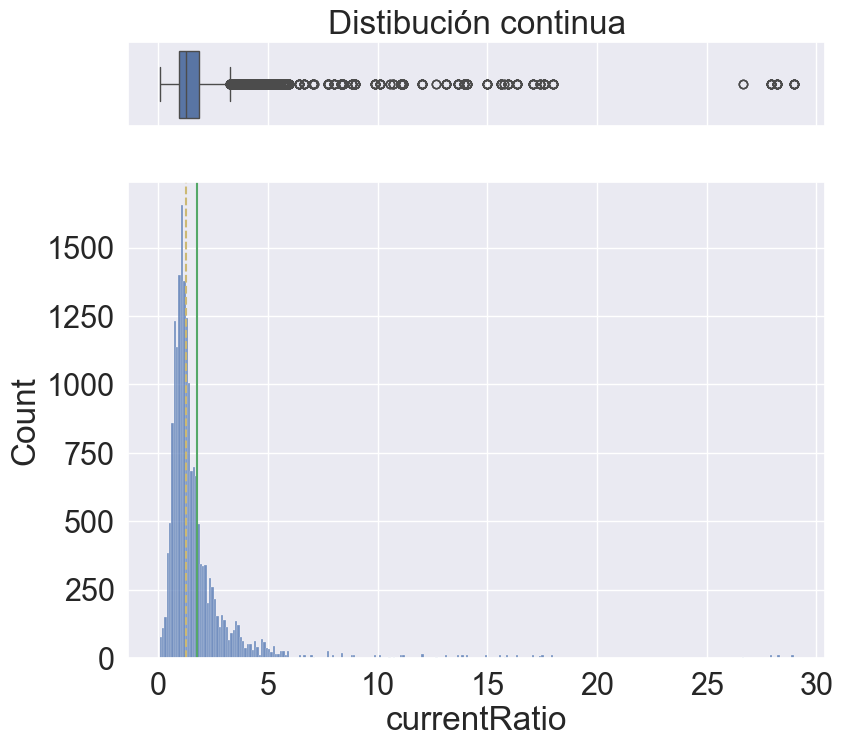

In [10]:
# Graficar
columna_a_graficar = 'currentRatio' # indicar columna para el grafico
plot(df_transformed[columna_a_graficar])

In [11]:
# Transformacion yeo-johnson sobre ratios de valuación
pt = PowerTransformer(method='yeo-johnson', standardize=True)
columnas_a_transformar = ['returnOnEquity', 'debtToEquity']
for columna in columnas_a_transformar:
    df_transformed[f'{columna}_Transformed'] = pt.fit_transform(df_transformed[[columna]])
    # Elimino la columna sin transformar
    df_transformed.drop(columna, axis=1, inplace=True)

In [12]:
# Transformaciones logarítmicas
columnas_a_transformar = [
    'RelativeAssets', 
    'RelativeRevenue',
    'RelativeEquity', 
    'Close', 
    'currentRatio'
    ]
for columna in columnas_a_transformar:
    df_transformed[f'{columna}_log'] = np.log1p(df_transformed[columna])
    df_transformed.drop(columna, axis=1, inplace=True)

# Coeficientes de asimetria actualizado
df_transformed.select_dtypes(include="number").skew()

Monthly_Return                 1.533070
Monthly_Variance              12.109906
Market_Covariance              1.354749
MarketCap                      8.296193
EnterpriseValue                8.157074
PE_Trailing                  -39.484640
EnterpriseToEbitda            13.565323
PriceToBook                    6.941248
operatingMargins              -0.434126
profitMargins                 -1.903186
ReturnOnAssets                 0.717931
Revenue_YoY                    3.996226
Revenue_QoQ                    8.383460
EBITDA_YoY                   -13.559846
EBITDA_QoQ                   -25.483343
FCF_YoY                       25.449104
FCF_QoQ                       46.969897
Capex_YoY                    -36.050697
Capex_QoQ                    -73.440363
NetDebt_to_EBITDA              5.967880
FCF_to_EBITDA                 13.979187
Capex_to_Revenue               2.803564
TotalAssets                    3.697225
TotalRevenue                   5.113921
TotalEquity                    5.850535


In [13]:
df_transformed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18052 entries, 0 to 18051
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Monthly_Return              18052 non-null  float64
 1   Monthly_Variance            18052 non-null  float64
 2   Market_Covariance           18052 non-null  float64
 3   MarketCap                   18052 non-null  float64
 4   EnterpriseValue             18052 non-null  float64
 5   PE_Trailing                 18052 non-null  float64
 6   EnterpriseToEbitda          18052 non-null  float64
 7   PriceToBook                 18052 non-null  float64
 8   operatingMargins            18052 non-null  float64
 9   profitMargins               18052 non-null  float64
 10  ReturnOnAssets              18052 non-null  float64
 11  Revenue_YoY                 18052 non-null  float64
 12  Revenue_QoQ                 18052 non-null  float64
 13  EBITDA_YoY                  180

In [14]:
# Definir columnas que saltean la "winsorización"
columnas_intactas = [
    'MarketCap', 
    'EnterpriseValue',
    'PE_Trailing',
    'EnterpriseToEbitda',
    'PriceToBook',
    'TotalAssets',
    'TotalRevenue',
    'TotalEquity', 
    'Date', 
    'Ticker', 
    'Close_log'    
    ]

# Separar el dataset
df_passthrough = df_transformed[columnas_intactas].copy()
df_transformed_features = df_transformed.drop(columns=columnas_intactas)

## Gestión de Outliers

Se winsorizan los valores atipicos en las variables continuas que cumplan los siguientes criterios:

Para variables simetricas:
* A mas de 3 desviaciones tipicas de la media.
* Mas de 3 rangos intercuartilicos.

Para variables asimetricas (modulo del coeficiente de asimetrica mayor a 1):
* A mas de 3 MADs de la mediana.
* Mas de 3 rangos intercuartilicos.

In [15]:
# Outliers
df_cont_transformed = df_transformed_features.select_dtypes(include="number")
df_winsor = df_cont_transformed.apply(lambda x: gestiona_outliers(x, clas='winsor'))

Monthly_Return
Monthly_Variance
Market_Covariance
operatingMargins
profitMargins
ReturnOnAssets
Revenue_YoY
Revenue_QoQ
EBITDA_YoY
EBITDA_QoQ
FCF_YoY
FCF_QoQ
Capex_YoY
Capex_QoQ
NetDebt_to_EBITDA
FCF_to_EBITDA
Capex_to_Revenue
returnOnEquity_Transformed
debtToEquity_Transformed
RelativeAssets_log
RelativeRevenue_log
RelativeEquity_log
currentRatio_log


In [16]:
# Coeficientes de asimetria luego de winsorizar
df_winsor.skew()

Monthly_Return                0.432932
Monthly_Variance              1.751229
Market_Covariance             1.027334
operatingMargins              0.532512
profitMargins                 0.152521
ReturnOnAssets                0.582887
Revenue_YoY                   0.165453
Revenue_QoQ                  -1.848115
EBITDA_YoY                    0.417343
EBITDA_QoQ                    0.794424
FCF_YoY                       0.690332
FCF_QoQ                       1.234709
Capex_YoY                    -0.856113
Capex_QoQ                     2.500859
NetDebt_to_EBITDA             0.404110
FCF_to_EBITDA                -0.263611
Capex_to_Revenue              1.719674
returnOnEquity_Transformed    0.887026
debtToEquity_Transformed      0.162717
RelativeAssets_log            1.721013
RelativeRevenue_log           1.669554
RelativeEquity_log            1.799568
currentRatio_log              1.235884
dtype: float64

Cont


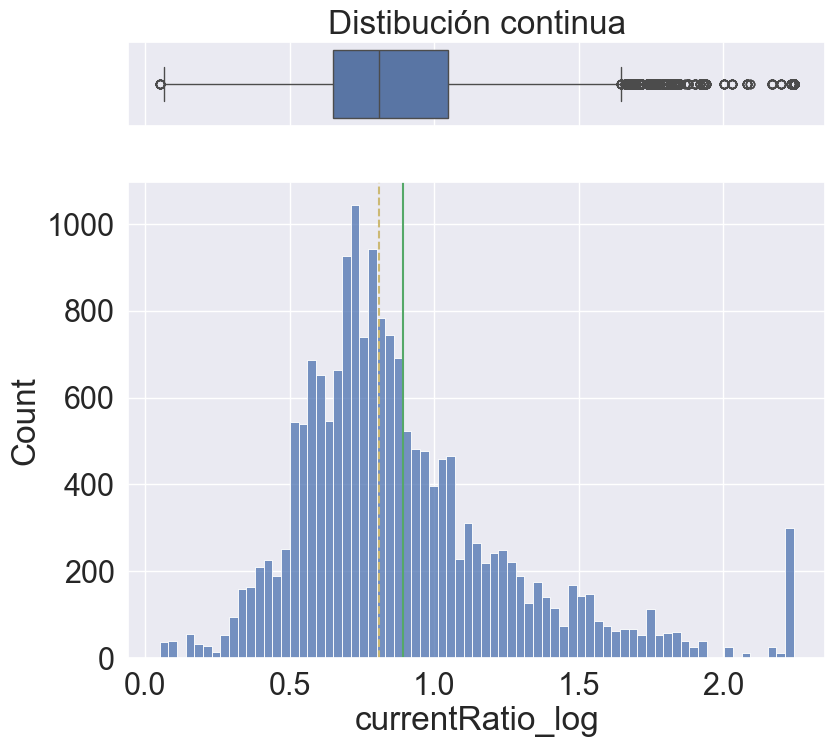

In [17]:
# Visualizar cambios
columna_a_graficar = 'currentRatio_log' # indicar columna para el grafico
plot(df_winsor[columna_a_graficar])

In [18]:
df_winsor.describe().T

,count,mean,std,min,25%,50%,75%,max
Monthly_Return,18052.0,0.013398,0.088565,-0.342330,-0.039769,0.011629,0.060864,0.363437
Monthly_Variance,18052.0,0.007820,0.006138,0.000622,0.003631,0.005946,0.009760,0.028177
Market_Covariance,18052.0,0.001633,0.001473,-0.003955,0.000637,0.001408,0.002371,0.007594
operatingMargins,18052.0,0.191485,0.140317,-0.359800,0.106200,0.177500,0.260400,0.741900
profitMargins,18052.0,0.136059,0.129742,-0.353200,0.066900,0.121500,0.197900,0.603100
ReturnOnAssets,18052.0,0.079306,0.076968,-0.227700,0.032900,0.063500,0.117300,0.388700
Revenue_YoY,18052.0,0.051297,0.103392,-0.259876,0.003662,0.045819,0.090911,0.354350
Revenue_QoQ,18052.0,0.000001,0.000009,-0.000031,0.000000,0.000000,0.000000,0.000012
EBITDA_YoY,18052.0,0.123575,0.332468,-0.766785,-0.012738,0.098041,0.238406,0.998414
EBITDA_QoQ,18052.0,0.000043,0.000111,-0.000147,0.000000,0.000000,0.000000,0.000237


# Variables Categoricas

In [19]:
df_cat_transformed = df_transformed_features.select_dtypes(exclude='number')

# Valores únicos
df_cat_transformed.nunique()

Sector        11
DateAdded    340
dtype: int64

In [20]:
# Convertir Sector a category
df_cat_transformed['Sector'] = df_cat_transformed['Sector'].astype('category')

# Valores unicos en Sector
df_cat_transformed['Sector'].value_counts()

Sector
Industrials              3123
InformationTechnology    2828
HealthCare               2239
ConsumerDiscretionary    1900
ConsumerStaples          1465
Financials               1268
Utilities                1213
RealEstate               1209
Materials                1025
CommunicationServices     925
Energy                    857
Name: count, dtype: int64

In [21]:
# Transformar DateAdded a datetime y convertir a YearsSinceAdded
df_cat_transformed['DateAdded'] = pd.to_datetime(df_cat_transformed['DateAdded'], errors='coerce')
df_cat_transformed['YearsSinceAdded'] = round(((pd.Timestamp.now() - df_cat_transformed['DateAdded']).dt.days / 365.25), 0)
df_cat_transformed.drop('DateAdded', axis=1, inplace=True)

In [22]:
# Merge de variables continuas transformadas y variables no numericas
df_combined = pd.concat([df_cat_transformed, df_winsor], axis=1)

# Unir con las columnas que fueron salteadas
df_final = pd.concat([df_passthrough, df_combined], axis=1)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18052 entries, 0 to 18051
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   MarketCap                   18052 non-null  float64 
 1   EnterpriseValue             18052 non-null  float64 
 2   PE_Trailing                 18052 non-null  float64 
 3   EnterpriseToEbitda          18052 non-null  float64 
 4   PriceToBook                 18052 non-null  float64 
 5   TotalAssets                 18052 non-null  float64 
 6   TotalRevenue                18052 non-null  float64 
 7   TotalEquity                 18052 non-null  float64 
 8   Date                        18052 non-null  object  
 9   Ticker                      18052 non-null  object  
 10  Close_log                   18052 non-null  float64 
 11  Sector                      18052 non-null  category
 12  YearsSinceAdded             18052 non-null  float64 
 13  Monthly_Return  

In [23]:
# Guardar datos extraidos en fichero clean_data
df_final.to_parquet(f"{data_folder}/clean_data.parquet")